In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

#rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'D:\Riset QSAR - TTX\Try on\Oral toxicity\dataset\train_set_acute_oral_features_rdkitcdk.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

print("Train DataFrame:")
print(train_df.head())
print(train_df.keys())


Train DataFrame:
        CASRN          DTXSID  \
0  62899-75-6             nan   
1  15351-05-0             nan   
2    633-99-8  DTXSID50212691   
3  68955-20-4   DTXSID8029523   
4  84731-70-4             nan   

                                                Name     Structure_Source  \
0                                                     Public_CrossChecked   
1                                                     Public_CrossChecked   
2                                1-Chloro-2-naphthol           EPA_DSSTox   
3  Sulfuric acid, mono-C16-18-alkyl esters, sodiu...           EPA_DSSTox   
4                                                     Public_CrossChecked   

                                     Canonical_QSARr Salt_Solvent  \
0                               CCN(C1CCCCC1)C(=O)Cl            ?   
1  C[N+]1(CCC(C(N)=O)(C2C=CC=CC=2)C2C=CC=CC=2)CCC...         [I-]   
2                             OC1C=CC2=CC=CC=C2C=1Cl            ?   
3                       CCCCCCCCCCCCCCCCCOS(O

In [3]:
train_df

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,62899-75-6,nan,,Public_CrossChecked,CCN(C1CCCCC1)C(=O)Cl,?,InChI=1S/C9H16ClNO/c1-2-11(9(10)12)8-6-4-3-5-7...,ONKIPJDBUYZQMP-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,2.0,5.0,0.5,3.0,0.0,20.31,4.584962500721156,2.499,0.8888888888888888
1,15351-05-0,nan,,Public_CrossChecked,C[N+]1(CCC(C(N)=O)(C2C=CC=CC=2)C2C=CC=CC=2)CCC...,[I-],InChI=1S/C23H30N2O/c1-25(17-10-2-3-11-18-25)19...,HDGFUOKLIQJQCS-UHFFFAOYSA-O,FALSE,TRUE,...,1.0,4.0,5.0,0.5,6.0,0.0,43.09,5.807354922057604,3.917,0.4347826086956521
2,633-99-8,DTXSID50212691,1-Chloro-2-naphthol,EPA_DSSTox,OC1C=CC2=CC=CC=C2C=1Cl,?,InChI=1S/C10H7ClO/c11-10-8-4-2-1-3-7(8)5-6-9(1...,RMSOEGBYNWXXBG-UHFFFAOYSA-N,FALSE,TRUE,...,1.0,0.0,0.0,0.5,0.0,0.0,20.23,4.700439718141093,3.504,0.0
3,68955-20-4,DTXSID8029523,"Sulfuric acid, mono-C16-18-alkyl esters, sodiu...",EPA_DSSTox,CCCCCCCCCCCCCCCCCOS(O)(=O)=O,[Na+],InChI=1S/C17H36O4S/c1-2-3-4-5-6-7-8-9-10-11-12...,KGIBGHABTNQVJX-UHFFFAOYSA-N,FALSE,FALSE,...,1.0,17.0,20.0,0.4736842105263157,17.0,2.0,71.98,5.392317422778761,6.951,1.0
4,84731-70-4,nan,,Public_CrossChecked,CCCCC(COC(=O)C1CCC(CC1)C(=O)OCC(CCCC)CC)CC,?,InChI=1S/C24H44O4/c1-5-9-11-19(7-3)17-27-23(25...,HOQGHOMLEVKTBY-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,7.0,9.0,0.4736842105263157,16.0,2.0,52.60000000000001,5.807354922057604,7.602,0.9166666666666666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6562,80464-05-7,nan,,Public_CrossChecked,CN(C)C1C=CC(=CC=1)NC(=O)CCCSC1=NN=NN1C,?,InChI=1S/C14H20N6OS/c1-19(2)12-8-6-11(7-9-12)1...,WKLKPZAMTNLNQV-UHFFFAOYSA-N,FALSE,FALSE,...,0.0,6.0,14.0,0.4615384615384615,9.0,0.0,52.60000000000001,4.906890595608519,1.1840000000000002,0.5
6563,64050-54-0,DTXSID60214181,"1H-Benz(de)isoquinoline-1,3(2H)-dione, 2-((dim...",EPA_DSSTox,COP(=O)(ON1C(=O)C2C=CC=C3C=CC=C(C3=2)C1=O)OC,?,"InChI=1S/C14H12NO6P/c1-19-22(18,20-2)21-15-13(...",SFWMYVAUEVMHSH-UHFFFAOYSA-N,FALSE,FALSE,...,3.0,0.0,3.0,0.4615384615384615,5.0,0.0,203.27,6.0,0.2239999999999998,0.0588235294117647
6564,6900-06-7,DTXSID90219043,"Adipic acid, di-2-propynyl ester",EPA_DSSTox,C#CCOC(=O)CCCCC(=O)OCC#C,?,InChI=1S/C12H14O4/c1-3-9-15-11(13)7-5-6-8-12(1...,UUKXRCZQOHIIPD-UHFFFAOYSA-N,FALSE,FALSE,...,1.0,2.0,2.0,0.5,3.0,0.0,41.57000000000001,5.392317422778761,1.929,0.5333333333333333
6565,6837-93-0,DTXSID00218502,"2,7-Naphthalenedisulfonic acid, 4-amino-5-hydr...",EPA_DSSTox,CC1C=CC(=CC=1)S(=O)(=O)OC1=CC(=CC2=CC(=CC(N)=C...,?,InChI=1S/C17H15NO9S3/c1-10-2-4-12(5-3-10)30(25...,ZIQWUYNDHGXLIN-UHFFFAOYSA-N,FALSE,TRUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
train_df = train_df[(train_df['Outcome']== '0')|(train_df['Outcome']== '1')]
train_df= train_df.sort_values(['Outcome'], ascending=True)

train_df.head(100)

,CASRN,DTXSID,Name,Structure_Source,Canonical_QSARr,Salt_Solvent,InChI_Code_QSARr,InChI Key_QSARr,very_toxic,nontoxic,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
2091,3618-72-2,DTXSID8027539,C.I. Disperse Blue 79:1,EPA_DSSTox,COC1=CC(N=NC2=C(Br)C=C(C=C2[N+]([O-])=O)[N+]([...,?,InChI=1S/C23H25BrN6O10/c1-13(31)25-18-11-20(28...,JSRUDOBCTLPTFO-UHFFFAOYSA-N,FALSE,TRUE,...,1.0,2.0,11.0,0.4705882352941176,16.0,2.0,205.17,6.357552004618084,4.162000000000002,0.3478260869565217
5153,132-82-1,DTXSID30157293,"Maleic anhydride, dihydroxy-, dibutyrate",EPA_DSSTox,CCCC(=O)OC1=C(OC(=O)CCC)C(=O)OC1=O,?,InChI=1S/C12H14O7/c1-3-5-7(13)17-9-10(12(16)19...,SMFDSCCTAOVFIJ-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,3.0,3.0,0.5,2.0,1.0,0.0,5.08746284125034,6.098000000000002,0.375
2516,15220-87-8,DTXSID8049757,Propylene pentamer,EPA_DSSTox,CC=CC=CC=CC=CC=CC=CC=C,?,InChI=1S/C15H18/c1-3-5-7-9-11-13-15-14-12-10-8...,CETJIWVTDUCJAH-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,15.0,15.0,0.5,6.0,1.0,0.0,4.807354922057604,5.950000000000002,0.0666666666666666
5152,2094-99-7,DTXSID9044871,1-(2-Isocyanatopropan-2-yl)-3-(prop-1-en-2-yl)...,EPA_DSSTox,CC(=C)C1=CC(=CC=C1)C(C)(C)N=C=O,?,InChI=1S/C13H15NO/c1-10(2)11-6-5-7-12(8-11)13(...,ZVEMLYIXBCTVOF-UHFFFAOYSA-N,FALSE,TRUE,...,2.0,0.0,4.0,0.4545454545454545,4.0,0.0,77.24,5.321928094887363,1.089,0.0769230769230769
5151,85162-11-4,DTXSID10234314,"4-Oxazoleacetic acid, 2-(p-fluorophenyl)-5-(3-...",EPA_DSSTox,OC(=O)CC1N=C(OC=1C1=CSC=C1)C1C=CC(F)=CC=1,?,InChI=1S/C15H10FNO3S/c16-11-3-1-9(2-4-11)15-17...,SCEWIPICHQDLEK-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,4.0,5.0,0.4545454545454545,8.0,0.0,95.97,5.247927513443585,1.719,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5114,40942-73-2,DTXSID00866027,"Cyclopentanone, 3-(2-oxopropyl)-2-pentyl-",EPA_DSSTox,CC(=O)CC1CCC(=O)C1CCCCC,?,InChI=1S/C13H22O2/c1-3-4-5-6-12-11(9-10(2)14)7...,PMVDYAQAPLAXSY-UHFFFAOYSA-N,FALSE,TRUE,...,1.0,0.0,4.0,0.4285714285714285,3.0,0.0,71.05000000000001,4.807354922057604,0.057,0.2222222222222222
5113,188425-85-6,DTXSID6034392,Boscalid,EPA_DSSTox,O=C(NC1C=CC=CC=1C1C=CC(Cl)=CC=1)C1C=CC=NC=1Cl,?,InChI=1S/C18H12Cl2N2O/c19-13-9-7-12(8-10-13)14...,WYEMLYFITZORAB-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,3.0,6.0,0.4545454545454545,5.0,0.0,84.46000000000001,5.0,2.7960000000000003,0.1818181818181818
2575,81-30-1,DTXSID4052554,"Naphthalene-1,8:4,5-tetracarboxylic dianhydride",EPA_DSSTox,O=C1OC(=O)C2=CC=C3C4=C2C1=CC=C4C(=O)OC3=O,?,InChI=1S/C14H4O6/c15-11-5-1-2-6-10-8(14(18)20-...,YTVNOVQHSGMMOV-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,0.0,0.0,0.4285714285714285,0.0,0.0,86.74000000000001,5.523561956057013,2.29,0.0
5112,18794-84-8,DTXSID9047049,trans-beta-Farnesene,EPA_DSSTox,CC(C)=CCCC(C)=CCCC(=C)C=C,?,InChI=1S/C15H24/c1-6-14(4)10-8-12-15(5)11-7-9-...,JSNRRGGBADWTMC-UHFFFAOYSA-N,FALSE,TRUE,...,0.0,5.0,5.0,0.4444444444444444,6.0,0.0,34.14,4.906890595608519,2.599,0.8461538461538461


Classes                          :  ['0' '1']
Number of cpds in each class     :  [2864 3690]
Total number of cpds             :  6554


{'0': 0, '1': 1}

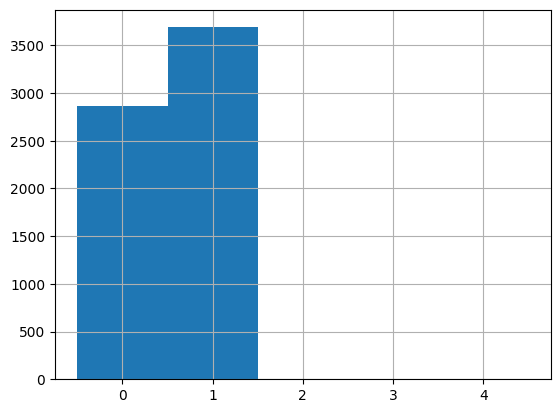

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(train_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( train_df['Outcome'] )

print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =train_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [6]:
y= np.int32((S))
def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
x = np.array(train_df['Modred_Descriptor'].tolist())

# Print the shape of the resulting array
print(f"x.shape: {x.shape}")
print(x)

x.shape: (6554, 730)
[[ 2.01834975e+00  5.81607189e-01  6.99326160e-01 ...  1.94872892e+00
   1.79770191e+00  2.29656484e+00]
 [-1.18293840e-03  5.04749446e-01  1.84643027e-01 ... -2.38438580e-02
  -4.43793018e-02  1.56401278e-01]
 [-3.39654048e-01 -1.74820007e+00 -1.74820654e+00 ... -6.56555881e-01
  -7.59898449e-01 -7.99358020e-02]
 ...
 [-4.51335089e-01 -1.65551478e-01 -8.55865258e-02 ... -4.70464110e-01
  -4.85869839e-01 -4.21311585e-01]
 [-3.80911179e-01 -2.82967378e-01 -2.08935466e-01 ... -3.96027401e-01
  -4.70646028e-01 -1.39020072e-01]
 [ 2.04522707e-01  5.47645381e-01  4.27097804e-01 ...  1.99466268e-01
   1.99201684e-01 -1.15677516e-03]]


In [7]:
print("x shape:", x.shape)
print("y shape:", y.shape)
print("Classes unik di y:", np.unique(y))
print("Jumlah kelas:", len(np.unique(y)))
print("Distribusi per kelas:", np.bincount(y))

x shape: (6554, 730)
y shape: (6554,)
Classes unik di y: [0 1]
Jumlah kelas: 2
Distribusi per kelas: [2864 3690]


In [10]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# parameter
paramgrid = {
    "n_estimators": [300,330],  
    "max_features": [
        int(np.sqrt(x.shape[1])),     
        int(x.shape[1] / 6)           
    ],
    "max_depth": [28,30,33],          
    "min_samples_leaf": [1,3],    
    "min_samples_split": [10]    
}

# Define the cross-validator as before
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

kappa_scorer = make_scorer(cohen_kappa_score)

model_rf_modred = GridSearchCV(estimator=RandomForestClassifier(class_weight='balanced'),
                     param_grid=paramgrid,
                     scoring=kappa_scorer,
                     cv=cv,
                     verbose=1,
                     n_jobs=-1) 

# Fit the model
model_rf_modred.fit(x, y)
best_model_rf_modred = model_rf_modred.best_estimator_


print("Best Params:", model_rf_modred.best_params_)
print("Best Score :", model_rf_modred.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'max_depth': 33, 'max_features': 121, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 300}
Best Score : 0.534150531879728


In [9]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_modred.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_modred.predict(X_test)
    y_proba = best_model_rf_modred.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[389 184]
 [122 616]]
Confusion Matrix for Fold 2:
[[379 194]
 [107 631]]
Confusion Matrix for Fold 3:
[[406 167]
 [123 615]]
Confusion Matrix for Fold 4:
[[393 180]
 [132 606]]
Confusion Matrix for Fold 5:
[[402 170]
 [116 622]]
Overall CV Accuracy: 0.7718965185948609
Overall CV AUC: 0.8445314655217604
Overall CV Precision: 0.7755278798803915
Overall CV Recall (Sensitivity): 0.83739837398374
Overall CV F1 Score: 0.8052039898930818
Overall CV Specificity: 0.6875053393378001
Overall CV PPV (Positive Predictive Value): 0.7755278798803915
Overall CV NPV (Negative Predictive Value): 0.7666413728139796
Overall CV CCR (Correct Classification Rate): 0.7624518566607699


In [11]:
# SVM 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
     "C": [2,10],  # Regularization parameter
     "kernel": ['rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient
}

# 5-fold stratified shuffle split
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen’s Kappa 
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights="quadratic"
)

# GridSearchCV
model_svm_modred = GridSearchCV(
    estimator=SVC(
        probability=True,
        class_weight="balanced",
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    refit=True,
    verbose=1,
    n_jobs=-1
)

# Fit model
model_svm_modred.fit(x, y)

# Best model
best_model_svm_modred = model_svm_modred.best_estimator_

print("Best Params:", model_svm_modred.best_params_)
print("Best Score :", model_svm_modred.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Score : 0.5218962533598039


In [11]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_modred.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_modred.predict(X_test)
    y_proba = best_model_svm_modred.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[422 151]
 [177 561]]
Confusion Matrix for Fold 2:
[[429 144]
 [149 589]]
Confusion Matrix for Fold 3:
[[430 143]
 [168 570]]
Confusion Matrix for Fold 4:
[[430 143]
 [180 558]]
Confusion Matrix for Fold 5:
[[425 147]
 [169 569]]
Overall CV Accuracy: 0.7602988220634559
Overall CV AUC: 0.8350368983589517
Overall CV Precision: 0.7963211697819529
Overall CV Recall (Sensitivity): 0.7715447154471544
Overall CV F1 Score: 0.7836962005501185
Overall CV Specificity: 0.7458090774844701
Overall CV PPV (Positive Predictive Value): 0.7963211697819529
Overall CV NPV (Negative Predictive Value): 0.7172383677636885
Overall CV CCR (Correct Classification Rate): 0.7586768964658124


In [ ]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_modred.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_modred.predict(X_test)
    y_proba = best_model_svm_modred.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


In [8]:
# XGB 
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "max_depth": [10,12,15],          
    "n_estimators": [300,330],           
    "learning_rate": [0.2,0.4],   
    "subsample": [0.8],              
    "colsample_bytree": [0.8],  
    "reg_lambda": [1, 2]            
}

# 5-fold stratified CV
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen's Kappa 
kappa_scorer = make_scorer(cohen_kappa_score)

model_xgb_modred = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=24,
        n_jobs=1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

model_xgb_modred.fit(x, y)
best_model_xgb_modred = model_xgb_modred.best_estimator_

print("Best Params:", model_xgb_modred.best_params_)
print("Best Score :", model_xgb_modred.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 330, 'reg_lambda': 2, 'subsample': 0.8}
Best Score : 0.5546739992934914


In [12]:
#XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_modred.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_modred.predict(X_test)
    y_proba = best_model_xgb_modred.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[403 170]
 [139 599]]
Confusion Matrix for Fold 2:
[[400 173]
 [111 627]]
Confusion Matrix for Fold 3:
[[422 151]
 [146 592]]
Confusion Matrix for Fold 4:
[[404 169]
 [146 592]]
Confusion Matrix for Fold 5:
[[409 163]
 [126 612]]
Overall CV Accuracy: 0.7720487245328721
Overall CV AUC: 0.849008351642115
Overall CV Precision: 0.7854109471809008
Overall CV Recall (Sensitivity): 0.8189701897018971
Overall CV F1 Score: 0.8017219932845748
Overall CV Specificity: 0.711593380441548
Overall CV PPV (Positive Predictive Value): 0.7854109471809008
Overall CV NPV (Negative Predictive Value): 0.7536620965455477
Overall CV CCR (Correct Classification Rate): 0.7652817850717225


In [9]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [(700,1200,1500),(256,512,1024)],  
    "activation": ['relu'],             
    "solver": ['adam'],              
    "alpha": [0.0005,0.05,0.1]                          
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_modred = GridSearchCV(
    estimator=MLPClassifier(max_iter=700, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# Fit the model
model_nn_modred.fit(x, y)
best_model_nn_modred = model_nn_modred.best_estimator_

print("Best Params:", model_nn_modred.best_params_)
print("Best Score :", model_nn_modred.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'activation': 'relu', 'alpha': 0.05, 'hidden_layer_sizes': (700, 1200, 1500), 'solver': 'adam'}
Best Score : 0.4874952930921731


In [13]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model
    best_model_nn_modred.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_nn_modred.predict(X_test)
    y_proba = best_model_nn_modred.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[412 161]
 [185 553]]
Confusion Matrix for Fold 2:
[[416 157]
 [170 568]]
Confusion Matrix for Fold 3:
[[392 181]
 [152 586]]
Confusion Matrix for Fold 4:
[[402 171]
 [179 559]]
Confusion Matrix for Fold 5:
[[411 161]
 [159 579]]
Overall CV Accuracy: 0.7442800496095866
Overall CV AUC: 0.8083306262497937
Overall CV Precision: 0.7740319164490364
Overall CV Recall (Sensitivity): 0.7710027100271003
Overall CV F1 Score: 0.7724007575068068
Overall CV Specificity: 0.7098494001635363
Overall CV PPV (Positive Predictive Value): 0.7740319164490364
Overall CV NPV (Negative Predictive Value): 0.706713245973061
Overall CV CCR (Correct Classification Rate): 0.7404260550953182


In [8]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "n_estimators": [300,350],
    "learning_rate": [0.1,0.2],
    "max_depth": [8,10],
    "min_child_samples": [20],
    "feature_fraction": [0.7],
    "bagging_fraction": [0.7],
    "bagging_freq": [1]
}

# Cross-validator 
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Scoring function
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_modred = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# fit model
model_lgbm_modred.fit(x, y)
best_model_lgbm_modred = model_lgbm_modred.best_estimator_

print("Best Params:", model_lgbm_modred.best_params_)
print("Best Score :", model_lgbm_modred.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'bagging_fraction': 0.7, 'bagging_freq': 1, 'feature_fraction': 0.7, 'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 300}
Best Score : 0.5376870429053993


In [9]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_modred.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_modred.predict(X_test)
    y_proba = best_model_lgbm_modred.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[409 164]
 [142 596]]
Confusion Matrix for Fold 2:
[[399 174]
 [119 619]]
Confusion Matrix for Fold 3:
[[417 156]
 [147 591]]
Confusion Matrix for Fold 4:
[[420 153]
 [144 594]]
Confusion Matrix for Fold 5:
[[418 154]
 [137 601]]
Overall CV Accuracy: 0.7726587128292022
Overall CV AUC: 0.846835990690543
Overall CV Precision: 0.7894324947140324
Overall CV Recall (Sensitivity): 0.813279132791328
Overall CV F1 Score: 0.8010798941169159
Overall CV Specificity: 0.720324875822258
Overall CV PPV (Positive Predictive Value): 0.7894324947140324
Overall CV NPV (Negative Predictive Value): 0.7499505455952149
Overall CV CCR (Correct Classification Rate): 0.766802004306793


In [11]:
import joblib

base_path = r"D:\Riset QSAR - TTX\Try on\Oral toxicity\model\fingerprint descriptor model"

joblib.dump(
    best_model_xgb_modred,
    fr"{base_path}\Model_Oral_toxicity_XGB_modred.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_modred,
    fr"{base_path}\Model_Oral_toxicity_NN_modred.pkl",
    compress=9
)

['D:\\Riset QSAR - TTX\\Try on\\Oral toxicity\\model\\fingerprint descriptor model\\Model_Oral_toxicity_NN_modred.pkl']